# Portable Speaker Demand Exercise

Canonical market definition:

- Amazon portable Bluetooth speakers
- Conditional on buying a speaker
- Drop products with price below `$35`
- Choices: `JBL`, `OontZ`, `Anker`, `Bose`, `DOSS`, `Other`

This notebook uses only `pandas`, `numpy`, `seaborn`, `matplotlib`, and `sklearn`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')

BASE = Path('/media/vast/amz_rec/codex_version_speakers_conditional_35plus/artifacts')
df = pd.read_parquet(BASE / 'canonical_speaker_exercise.parquet', engine='fastparquet') ### Core dataset
choices = pd.read_parquet(BASE / 'canonical_user_year_choices.parquet', engine='fastparquet')

df = df[df['year'] >= 2015].copy()
choices = choices[choices['year'] >= 2015].copy()

df.head()

,year,split,choice,chosen_users,speaker_buyers,share_among_speaker_buyers,avg_price,avg_rating,waterproof_share,party_share,voice_assistant_share,n_choice_rows,hhi_inside
0,2015,train,Anker,79,20029,0.003944,63.329873,4.529114,0.000000,0.000000,0.000000,79,0.472801
1,2015,train,Bose,4212,20029,0.210295,141.189855,4.533974,0.000000,0.000000,0.000000,4212,0.472801
2,2015,train,JBL,2832,20029,0.141395,78.035332,4.383510,0.000353,0.000000,0.000000,2832,0.472801
3,2015,train,OontZ,104,20029,0.005192,45.456538,3.659615,0.000000,0.000000,0.903846,104,0.472801
4,2015,train,Other,12802,20029,0.639173,134.215901,4.175402,0.060381,0.084596,0.028902,12802,0.472801


In [2]:
choices.head()

,user_id,year,choice,brand,parent_asin,product_title,price_final,average_rating,waterproof_flag,party_flag,voice_assistant_flag,purchase_dt,split
0,AE224SS3CBECXN5SGPRY5WW7TU4Q,2015,JBL,jbl,B00GAJ2OK4,JBL Flip 2 Portable Wireless Speaker (Black),55.00,4.5,False,False,False,2015-05-24 23:39:26,train
1,AE22AIEZGF67Z65KRCQGPLGVDZRQ,2015,Other,unknown,B00KWU863Q,"Logitech X300 Mobile Wireless Stereo Speaker, ...",39.95,4.3,False,False,False,2015-01-28 21:14:58,train
2,AE22ZDVFW5T2Y37QBP2W6HP2LMWA,2015,Other,creative,B003N9PJDI,Creative D200 Bluetooth Speaker,49.99,4.4,False,False,False,2015-03-17 01:35:18,train
3,AE23CACEREJI2O6X7RWTNRF2NUDQ,2015,Bose,bose,B01AS57B0I,Bose SoundLink Color Bluetooth Speaker (Blue),99.99,4.6,False,False,False,2015-02-14 18:14:52,train
4,AE23GFJX7BXK77S7C34AHWXPCJEQ,2015,Other,jawbone,B0087BDWBI,"Jawbone Jambox Bluetooth Speaker, Diamond Blac...",69.99,4.3,False,False,False,2015-06-15 19:54:38,train


## 1. Market Shares Over Time

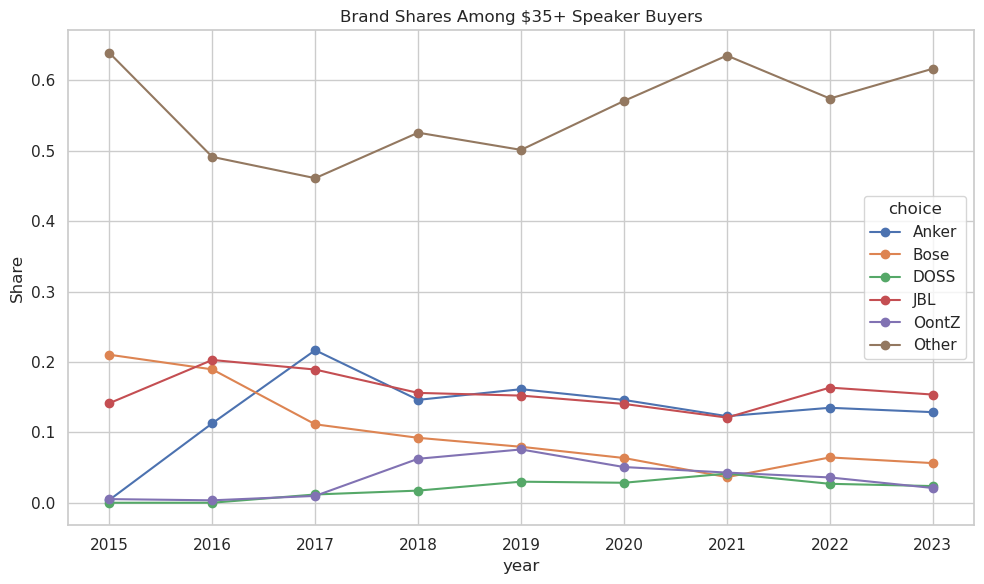

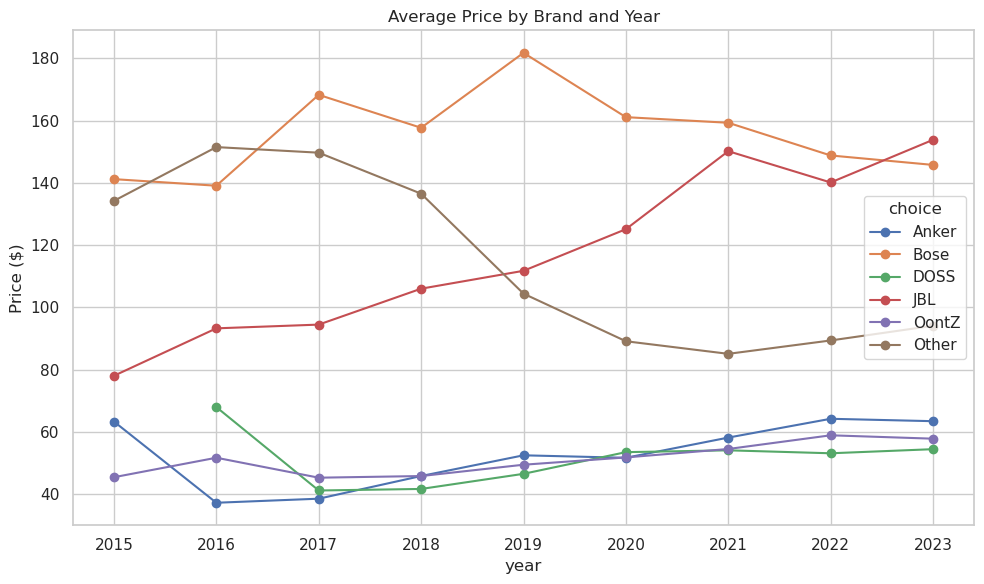

In [5]:
share_pivot = df.pivot(index='year', columns='choice', values='share_among_speaker_buyers').fillna(0)
price_pivot = df.pivot(index='year', columns='choice', values='avg_price').fillna(np.nan)

fig, ax = plt.subplots(figsize=(10, 6))
share_pivot.plot(marker='o', ax=ax)
ax.set_title('Brand Shares Among $35+ Speaker Buyers')
ax.set_ylabel('Share')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
price_pivot.plot(marker='o', ax=ax)
ax.set_title('Average Price by Brand and Year')
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

## 2. Estimate the Demand System

We estimate a simple conditional logit-style equation.

Let `Other` be the base choice. For each brand-year row,

$$\delta_{jt} = \log(s_{jt}) - \log(s_{Other,t})$$

Then regress `delta` on price, rating, product characteristics, brand dummies, and year dummies.

In [4]:
base_choice = 'Other'
base_df = df[df['choice'] == base_choice][['year', 'share_among_speaker_buyers']].rename(columns={'share_among_speaker_buyers': 'base_share'})
reg_df = df[df['choice'] != base_choice].merge(base_df, on='year', how='left').copy()
reg_df['delta'] = np.log(reg_df['share_among_speaker_buyers'].clip(lower=1e-12)) - np.log(reg_df['base_share'].clip(lower=1e-12))

X = reg_df[['avg_price', 'avg_rating', 'waterproof_share', 'party_share', 'voice_assistant_share']].copy()
X = pd.concat([
    X,
    pd.get_dummies(reg_df['choice'], prefix='choice', drop_first=True),
    pd.get_dummies(reg_df['year'], prefix='year', drop_first=True),
], axis=1)

y = reg_df['delta'].copy()
model = LinearRegression()
model.fit(X, y)

coef = pd.Series(model.coef_, index=X.columns).sort_values()
coef

waterproof_share        -3.839633
avg_price               -0.060613
year_2016                0.081771
year_2017                1.074972
year_2018                1.363930
year_2020                1.504579
year_2023                1.680606
choice_DOSS              1.745747
year_2021                1.838819
year_2019                2.051557
year_2022                2.141313
choice_OontZ             3.499626
voice_assistant_share    4.030405
choice_JBL               6.291683
choice_Bose              7.896362
avg_rating               9.036807
party_share              9.475497
dtype: float64

In [ ]:
price_coef = float(pd.Series(model.coef_, index=X.columns)['avg_price'])
price_coef

## 3. Plot Brand-Year Demand Shifters

A simple way to visualize brand-year demand is to remove the common price effect from `delta`.

In [ ]:
reg_df['pred_delta'] = model.predict(X)
reg_df['brand_year_shifter'] = reg_df['delta'] - price_coef * reg_df['avg_price']

shifter_pivot = reg_df.pivot(index='year', columns='choice', values='brand_year_shifter').fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
shifter_pivot.plot(marker='o', ax=ax)
ax.set_title('Residualized Brand-Year Demand Shifters')
ax.set_ylabel('Utility Index')
plt.tight_layout()
plt.show()

## 4. Revenue and Numerical Demand Derivatives

Use the fitted model to reconstruct inside shares and then approximate

$$D'(p) \approx \frac{D(p+1) - D(p-1)}{2}$$

In [ ]:
coef_series = pd.Series(model.coef_, index=X.columns)
intercept = float(model.intercept_)

def utility_for_row(row, price_override=None):
    price = row['avg_price'] if price_override is None else price_override
    value = intercept
    value += coef_series.get('avg_price', 0.0) * price
    value += coef_series.get('avg_rating', 0.0) * row['avg_rating']
    value += coef_series.get('waterproof_share', 0.0) * row['waterproof_share']
    value += coef_series.get('party_share', 0.0) * row['party_share']
    value += coef_series.get('voice_assistant_share', 0.0) * row['voice_assistant_share']
    choice_key = f"choice_{row['choice']}"
    year_key = f"year_{row['year']}"
    value += coef_series.get(choice_key, 0.0)
    value += coef_series.get(year_key, 0.0)
    return value

results = []

for year, year_df in reg_df.groupby('year'):
    year_rows = year_df.to_dict(orient='records')
    base_row = df[(df['year'] == year) & (df['choice'] == 'Other')].iloc[0]
    buyers = float(base_row['speaker_buyers'])

    base_utils = {row['choice']: utility_for_row(row) for row in year_rows}
    base_exp = {k: np.exp(v) for k, v in base_utils.items()}
    base_denom = 1.0 + sum(base_exp.values())
    base_shares = {k: v / base_denom for k, v in base_exp.items()}
    base_shares['Other'] = 1.0 / base_denom

    for row in year_rows:
        choice = row['choice']
        price = float(row['avg_price'])

        plus_utils = base_utils.copy()
        minus_utils = base_utils.copy()
        plus_utils[choice] = utility_for_row(row, price_override=price + 1.0)
        minus_utils[choice] = utility_for_row(row, price_override=price - 1.0)

        plus_exp = {k: np.exp(v) for k, v in plus_utils.items()}
        minus_exp = {k: np.exp(v) for k, v in minus_utils.items()}
        plus_denom = 1.0 + sum(plus_exp.values())
        minus_denom = 1.0 + sum(minus_exp.values())

        plus_share = plus_exp[choice] / plus_denom
        minus_share = minus_exp[choice] / minus_denom
        base_share = base_shares[choice]

        demand = buyers * base_share
        dprime = buyers * (plus_share - minus_share) / 2.0
        revenue = price * demand

        results.append({
            'year': year,
            'choice': choice,
            'avg_price': price,
            'avg_rating': row['avg_rating'],
            'share_inside': base_share,
            'demand_users': demand,
            'dprime': dprime,
            'revenue': revenue,
        })

econ = pd.DataFrame(results).sort_values(['year', 'choice']).reset_index(drop=True)
econ.head()

## 5. Markups, Marginal Costs, and Profits

Use the simple one-product formula:

$$\text{markup} \approx -\frac{D(p)}{D'(p)}$$

$$c \approx p - \text{markup}$$

$$\pi \approx (p - c)D(p)$$

In [ ]:
econ['markup'] = -econ['demand_users'] / econ['dprime']
econ['marginal_cost'] = econ['avg_price'] - econ['markup']
econ['profit'] = (econ['avg_price'] - econ['marginal_cost']) * econ['demand_users']

econ[['year', 'choice', 'avg_price', 'demand_users', 'dprime', 'markup', 'marginal_cost', 'profit']].head(15)

In [ ]:
econ[['markup', 'marginal_cost', 'profit']].describe().round(2)

## 6. Quality Relationships

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.scatterplot(data=econ, x='avg_rating', y='profit', hue='choice', ax=axes[0])
axes[0].set_title('Profit vs Quality')

sns.scatterplot(data=econ, x='avg_rating', y='marginal_cost', hue='choice', ax=axes[1], legend=False)
axes[1].set_title('Marginal Cost vs Quality')

sns.scatterplot(data=econ, x='avg_rating', y='avg_price', hue='choice', ax=axes[2], legend=False)
axes[2].set_title('Price vs Quality')

plt.tight_layout()
plt.show()

## Interpretation

- The common price coefficient tells us whether higher prices reduce conditional demand.
- Brand-year shifters capture residual popularity after controlling for price and observables.
- The markup and marginal-cost calculations are model-based and should be treated as implied, not directly observed.
- If any results look odd, that opens the door to a discussion of omitted quality, heterogeneity, and model misspecification.